In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import logging
from tqdm import tqdm

from eq_mag_prediction.utilities import data_utils

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)


2026-02-19 11:32:18.951442: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 11:32:19.021322: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-19 11:32:19.885045: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-19 11:32:19.885179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-19 11:32:19.964022: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
logger.info("Loading catalog data...")
catalog = data_utils.hauksson_dataframe()
logger.info(f"Loaded catalog with {len(catalog)} events")
catalog


2026-02-19 11:32:26 - INFO - Loading catalog data...
2026-02-19 11:32:28 - INFO - Loaded catalog with 266662 events


,event_id,latitude,longitude,depth,magnitude,strike,dip,rake,time,x_utm,y_utm
0,3301565,33.25517,-115.96750,5.68,2.26,318,57,-168,3.471704e+08,596175.343626,3.680051e+06
1,3301566,34.18600,-117.29733,6.49,2.37,0,49,-94,3.471744e+08,472602.164303,3.782820e+06
2,3301567,34.18433,-117.29600,6.75,1.60,326,55,-163,3.471756e+08,472724.181674,3.782634e+06
3,3301570,34.00633,-117.16200,15.35,1.88,348,70,-161,3.471854e+08,485040.753445,3.762870e+06
4,3301572,34.09367,-117.30517,16.46,1.40,210,61,-97,3.471947e+08,471849.133223,3.772584e+06
...,...,...,...,...,...,...,...,...,...,...,...
266657,39900127,33.38267,-116.86733,4.50,1.03,162,82,-169,1.640978e+09,512339.706055,3.693719e+06
266658,39900159,34.03983,-117.20350,14.52,3.38,151,78,179,1.640979e+09,481215.977032,3.766591e+06
266659,39900183,34.20850,-117.49767,7.28,1.22,150,68,147,1.640982e+09,454153.632695,3.785386e+06
266660,39900287,33.38317,-116.86250,4.07,2.14,137,48,157,1.640993e+09,512788.874019,3.693775e+06


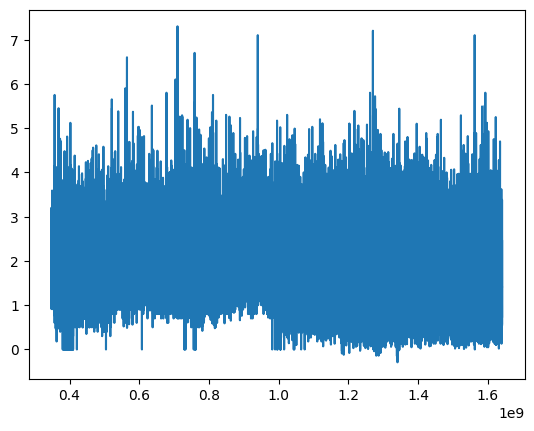

In [3]:
plt.plot(catalog.time, catalog.magnitude)


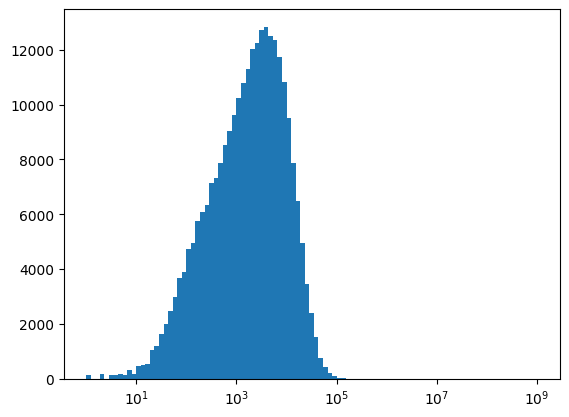

In [4]:
plt.hist(np.diff(catalog.time.values[20:-100]), np.logspace(0, 9, 100))
plt.xscale('log')


In [5]:
# TODO: "mu" should be a function of space
params = {
    "mu": 0.1,
    "beta": np.log(10),
    "alpha": 1,
    "gamma": 1.3,
    "c": -2.2,
    "p": 1,
    "D": 1,
    "q": 1,
    "m0": 1,
}

mu = lambda x,y: params["mu"]
kappa = lambda m, A=1: A*np.exp(-params["alpha"]*(m-params["m0"]))
g = lambda t: (params["p"]-1)/params["c"] * (1+t/params["c"])**(-params["p"])
f = lambda x,y,m: (params["q"]-1)/(np.pi*params["D"]**2 * kappa(m)) * (1+(x**2 + y**2)/(params["D"]**2 * kappa(m)))**(-params["q"])
summand = lambda x,y,m,t: kappa(m) * f(x,y,m) * g(t)


In [6]:
start_forecast = 1.2e9
end_forecast = 1.2005e9
dt = 1

time_vec = np.arange(start_forecast, end_forecast, dt)

history = catalog[catalog.time < start_forecast]
logger.info(f"Forecast period: {start_forecast:.2e} to {end_forecast:.2e}")
logger.info(f"History contains {len(history)} events before forecast start")


2026-02-19 11:32:29 - INFO - Forecast period: 1.20e+09 to 1.20e+09
2026-02-19 11:32:29 - INFO - History contains 147816 events before forecast start


In [7]:
# Spatial boundaries
x_min, x_max = history.x_utm.min(), history.x_utm.max()
y_min, y_max = history.y_utm.min(), history.y_utm.max()

# Grid size
dx = 1
dy = 1

# Grid
x_grid = np.linspace(x_min, x_max, 4)
y_grid = np.linspace(y_min, y_max, 4)
XX, YY = np.meshgrid(x_grid, y_grid)
logger.info(f"Spatial grid: {XX.shape[0]}x{XX.shape[1]} = {XX.size} grid points")
logger.info(f"X range: [{x_min:.2f}, {x_max:.2f}], Y range: [{y_min:.2f}, {y_max:.2f}]")


2026-02-19 11:32:29 - INFO - Spatial grid: 4x4 = 16 grid points
2026-02-19 11:32:29 - INFO - X range: [101397.05, 726220.32], Y range: [3523806.36, 4203603.61]


In [8]:
XX.shape


(4, 4)

In [9]:
def magnitude_gen(n, m0=params["m0"], beta=params["beta"]):
    np.random.seed(42)
    return np.random.exponential(scale=1/beta, size=n) + m0


In [10]:
def get_time_step(
    rate_function: callable,
    current_time: float,
    ):
    B = rate_function(current_time)
    dt =  np.random.exponential(scale=1/B)
    future_rate = rate_function(current_time + dt)
    U = np.random.uniform(0,1)
    reject = U >= future_rate/B
    return (dt, reject)

def propagate_catalog(
    rate_function: callable,
    current_time: float,
    catalog: pd.DataFrame,
    x_utm: float,
    y_utm: float,
    ):
    dt, reject = get_time_step(rate_function, current_time)
    if not reject:
        catalog.append({'time':current_time + dt, 'magnitude':magnitude_gen(1), 'x_utm':x_utm, 'y_utm':y_utm}, ignore_index=True)
    return current_time + dt


In [16]:
def return_local_rate(history, x, y):
    def current_local_rate(t0):
        local_intensity = 0
        for row in history.itertuples():
            x_k, y_k = row.x_utm, row.y_utm
            m_k = row.magnitude
            t_k = row.time
            local_intensity += kappa(m_k) * f(x-x_k,y-y_k,m_k) * g(t0-t_k)
        return mu(x,y) + local_intensity
    return current_local_rate

# Vectorized rate function for all grid points (OPTIMIZED - unified version)
def rate_at_t_all_grid(t_days, x_flat, y_flat, h_x, h_y, h_m, h_t_days):
    """
    Compute ETAS intensity at time(s) for all grid points.
    
    Args:
        t_days: Current time (in days) - scalar
        x_flat: 1D array of x coordinates for all grid points
        y_flat: 1D array of y coordinates for all grid points
        h_x: 1D array of x coordinates from history
        h_y: 1D array of y coordinates from history
        h_m: 1D array of magnitudes from history
        h_t: 1D array of times from history (in days)
    
    Returns:
        1D array of intensities at each grid point
    """
    n_grid = len(x_flat)
    local_intensity = np.zeros(n_grid)
    
    # Loop over events (vectorized operations inside)
    for k in range(len(h_x)):
        x_k, y_k, m_k, t_k_days = h_x[k], h_y[k], h_m[k], h_t_days[k]
        
        # Vectorized computation for all grid points
        dx = x_flat - x_k
        dy = y_flat - y_k
        kappa_val = kappa(m_k)
        f_vals = f(dx, dy, m_k)
        # g() handles scalar or array input - numpy broadcasting handles it
        g_vals = g(t_days - t_k_days)
        
        local_intensity += kappa_val * f_vals * g_vals
    
    # Add background rate (mu is constant)
    mu_val = mu(x_flat[0], y_flat[0])  # mu doesn't depend on x,y
    return mu_val + local_intensity


In [ ]:
# estimate the rate for each pixel at each time step
# Precompute grid arrays once (optimization)
x_flat = XX.flatten()
y_flat = YY.flatten()
n_grid = x_flat.size



logger.info("Starting ETAS simulation...")
forecast_cat = pd.DataFrame({'time':[None], 'magnitude':[None], 'x_utm':[None], 'y_utm':[None]})
t = start_forecast
total_time_steps = (end_forecast - start_forecast) / dt
events_generated = 0
iterations = 0

# Create progress bar for main loop
pbar = tqdm(total=end_forecast - start_forecast, unit='time', desc='Simulation progress', 
            initial=0, bar_format='{l_bar}{bar}| {n:.2e}/{total:.2e} [{elapsed}<{remaining}, {rate_fmt}]')

# for i,t in enumerate(time_vec):
while t < end_forecast:
    iterations += 1
    # time_step_events = {'time':[], 'magnitude':[], 'x_utm':[], 'y_utm':[]}
    # # iterate upon gridpoints
    # summed_intensity = np.empty_like(XX)
    # dt_vec = []
    # reject_vec = []
    
    # # Progress bar for grid point iteration
    # grid_points = list(zip(XX.flatten(), YY.flatten()))
    # for x, y in tqdm(grid_points, desc=f'  Grid points (iter {iterations})', 
    #                  leave=False, disable=len(grid_points) < 10):
    #     current_local_rate = return_local_rate(history, x, y)
    #     dt, reject = get_time_step(current_local_rate, t)   # dt is in days
    #     dt_vec.append(dt)
    #     reject_vec.append(reject)
    

        # Extract history to numpy arrays at start of iteration (ensures latest history is used)
    h_x = history['x_utm'].values
    h_y = history['y_utm'].values
    h_m = history['magnitude'].values
    h_t_days = history['time'].values / 86400.0
    
    # Vectorized rate computation at current time t for all grid points
    B = rate_at_t_all_grid(t/86400.0, x_flat, y_flat, h_x, h_y, h_m, h_t_days)
    
    # Vectorized thinning step: sample dt for each grid point
    # Avoid division by zero by clipping B to a small positive value
    dt_vec = np.random.exponential(1 / np.clip(B, 1e-15, None))  # dt_vec is in days
    
    # Vectorized rate computation at future times t+dt_vec for all grid points
    rate_future = rate_at_t_all_grid(t/86400.0 + dt_vec, x_flat, y_flat, h_x, h_y, h_m, h_t_days)
    
    # Vectorized rejection sampling
    U = np.random.uniform(size=n_grid)
    reject_vec = U >= (rate_future / B)


    # dt_vec = np.array(dt_vec)
    # reject_vec = np.array(reject_vec)
    # Find the smallest dt where reject_vec is False
    valid_dt = dt_vec[~reject_vec]
    min_dt = valid_dt.min() if valid_dt.size > 0 else None

    if min_dt is None:
        # All proposals rejected: use random choice
        min_dt = np.random.choice(dt_vec)
        logger.debug(f"Iteration {iterations}: No valid dt found, using random choice: {min_dt:.2e} days")
    else:
        # x = XX.flatten()[np.argmin(dt_vec)]
        # y = YY.flatten()[np.argmin(dt_vec)]
        # Find winner index: smallest accepted dt (FIX: use valid indices, not global argmin)
        valid_idx = np.flatnonzero(~reject_vec)
        winner = valid_idx[np.argmin(dt_vec[valid_idx])]
        
        x = x_flat[winner]
        y = y_flat[winner]

        mag_array = magnitude_gen(1)
        mag_value = mag_array.item() if isinstance(mag_array, np.ndarray) else mag_array
        # catalog_append = {'time':t+min_dt, 'magnitude':mag_value, 'x_utm':x, 'y_utm':y}
        lon, lat = data_utils.PROJECTIONS['california'](x, y, inverse=True)
        catalog_append = {'time':t+(min_dt * 86400), 'magnitude':mag_value, 'x_utm':x, 'y_utm':y, 'longitude':lon, 'latitude':lat}

        history.loc[len(history)] = catalog_append
        events_generated += 1
        logger.debug(f"Iteration {iterations}: Generated event at t={t+min_dt * 86400:.2e}, m={mag_value:.2f}")
    
    # t += min_dt * 86400  # Convert min_dt to seconds
    # pbar.update(min_dt * 86400)
    
    # Log progress every 100 iterations
    if iterations % 100 == 0:
        logger.info(f"Iteration {iterations}: t={t:.2e}, events={events_generated}, history_size={len(history)}")
        # Update time (convert min_dt from days to seconds)
    t += min_dt * 86400
    
    # Update progress bar (guard against None min_dt)
    if min_dt is not None:
        pbar.update(min_dt * 86400)


pbar.close()
logger.info(f"Simulation complete: {iterations} iterations, {events_generated} events generated")
logger.info(f"Final catalog size: {len(history)} events")


2026-02-19 11:35:35 - INFO - Starting ETAS simulation...
Simulation progress:  10%|█         | 5.21e+04/5.00e+05 [01:24<12:10, 612.92time/s] 
Simulation progress:  97%|█████████▋| 4.85e+05/5.00e+05 [02:58<00:05, 2794.69time/s]

TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
events_generated


28

In [18]:
t


1200503176.8591175

In [19]:
history


,event_id,latitude,longitude,depth,magnitude,strike,dip,rake,time,x_utm,y_utm
0,3301565.0,33.25517,-115.96750,5.68,2.260000,318.0,57.0,-168.0,3.471704e+08,596175.343626,3.680051e+06
1,3301566.0,34.18600,-117.29733,6.49,2.370000,0.0,49.0,-94.0,3.471744e+08,472602.164303,3.782820e+06
2,3301567.0,34.18433,-117.29600,6.75,1.600000,326.0,55.0,-163.0,3.471756e+08,472724.181674,3.782634e+06
3,3301570.0,34.00633,-117.16200,15.35,1.880000,348.0,70.0,-161.0,3.471854e+08,485040.753445,3.762870e+06
4,3301572.0,34.09367,-117.30517,16.46,1.400000,210.0,61.0,-97.0,3.471947e+08,471849.133223,3.772584e+06
...,...,...,...,...,...,...,...,...,...,...,...
147840,NaN,NaN,NaN,NaN,1.203801,NaN,NaN,NaN,1.200431e+09,309671.473057,3.977005e+06
147841,NaN,NaN,NaN,NaN,1.203801,NaN,NaN,NaN,1.200449e+09,309671.473057,3.977005e+06
147842,NaN,NaN,NaN,NaN,1.203801,NaN,NaN,NaN,1.200467e+09,309671.473057,3.977005e+06
147843,NaN,NaN,NaN,NaN,1.203801,NaN,NaN,NaN,1.200485e+09,309671.473057,3.977005e+06


In [25]:
for index, row in history.iterrows():
    # if pd.isna(row.longitude) or pd.isna(row.latitude):
    lon, lat = data_utils.PROJECTIONS['california'](row.x_utm, row.y_utm, inverse=True)
    history.loc[index, 'longitude'] = lon
    history.loc[index, 'latitude'] = lat

history 


,event_id,latitude,longitude,depth,magnitude,strike,dip,rake,time,x_utm,y_utm
0,3301565.0,33.255170,-115.967500,5.68,2.260000,318.0,57.0,-168.0,3.471704e+08,596175.343626,3.680051e+06
1,3301566.0,34.186000,-117.297330,6.49,2.370000,0.0,49.0,-94.0,3.471744e+08,472602.164303,3.782820e+06
2,3301567.0,34.184330,-117.296000,6.75,1.600000,326.0,55.0,-163.0,3.471756e+08,472724.181674,3.782634e+06
3,3301570.0,34.006330,-117.162000,15.35,1.880000,348.0,70.0,-161.0,3.471854e+08,485040.753445,3.762870e+06
4,3301572.0,34.093670,-117.305170,16.46,1.400000,210.0,61.0,-97.0,3.471947e+08,471849.133223,3.772584e+06
...,...,...,...,...,...,...,...,...,...,...,...
147840,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200431e+09,309671.473057,3.977005e+06
147841,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200449e+09,309671.473057,3.977005e+06
147842,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200467e+09,309671.473057,3.977005e+06
147843,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200485e+09,309671.473057,3.977005e+06


In [ ]:
start_forecast


,event_id,latitude,longitude,depth,magnitude,strike,dip,rake,time,x_utm,y_utm
0,3301565.0,33.255170,-115.967500,5.68,2.260000,318.0,57.0,-168.0,3.471704e+08,596175.343626,3.680051e+06
1,3301566.0,34.186000,-117.297330,6.49,2.370000,0.0,49.0,-94.0,3.471744e+08,472602.164303,3.782820e+06
2,3301567.0,34.184330,-117.296000,6.75,1.600000,326.0,55.0,-163.0,3.471756e+08,472724.181674,3.782634e+06
3,3301570.0,34.006330,-117.162000,15.35,1.880000,348.0,70.0,-161.0,3.471854e+08,485040.753445,3.762870e+06
4,3301572.0,34.093670,-117.305170,16.46,1.400000,210.0,61.0,-97.0,3.471947e+08,471849.133223,3.772584e+06
...,...,...,...,...,...,...,...,...,...,...,...
147840,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200431e+09,309671.473057,3.977005e+06
147841,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200449e+09,309671.473057,3.977005e+06
147842,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200467e+09,309671.473057,3.977005e+06
147843,NaN,35.918857,-119.109458,NaN,1.203801,NaN,NaN,NaN,1.200485e+09,309671.473057,3.977005e+06


In [ ]:
from eq_mag_prediction.utilities


In [ ]:
histor
